# Conservation of mass

Mass is conserved in a fixed control volume: the rate of change of the mass inside
equals the net mass flow in through the surface. This notebook writes that statement
as the continuity equation and checks its discrete form on two velocity fields.

One field satisfies the equation exactly. The other has a known, non-zero divergence,
which gives an error to measure on a sequence of grids.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 150, "font.size": 11,
                     "figure.constrained_layout.use": True})
FIG = "figures"

## Step 1. Inputs

In [2]:
L   = 1.0    # side of the square domain [m]
N   = 41     # cells per direction on the working grid
U0  = 1.0    # velocity scale [m/s]
rho = 1.0    # density, constant [kg/m^3]

N_LIST = [11, 21, 41, 81, 161, 321]   # grids for the refinement study, Step 6
BOX    = (0.10, 0.60, 0.20, 0.80)     # control volume x1, x2, y1, y2 [m], Step 5
N_FINE = 161                          # grid used for the cover figure, Step 7

## Step 2. Grid

Cell-centred grid on the square. Cell $i$ has its centre at $x_i=(i+\tfrac12)\Delta x$
with $\Delta x=L/N$, so no node sits on the boundary. Arrays are indexed `[j, i]`:
row `j` is the $y$ position and column `i` is the $x$ position.

In [3]:
def grid(n):
    """Cell-centred grid on [0, L] x [0, L]. Returns x, X, Y, dx."""
    dx = L / n
    x = (np.arange(n) + 0.5) * dx
    X, Y = np.meshgrid(x, x)
    return x, X, Y, dx

x, X, Y, dx = grid(N)
print(f"N = {N} cells per direction, dx = {dx:.6f} m")

N = 41 cells per direction, dx = 0.024390 m


## Step 3. Velocity fields

Field A is the Taylor-Green field,

$$u = U_0\sin\frac{\pi x}{L}\cos\frac{\pi y}{L},\qquad
  v = -U_0\cos\frac{\pi x}{L}\sin\frac{\pi y}{L}.$$

Differentiating gives $\partial u/\partial x = +(\pi U_0/L)\cos(\pi x/L)\cos(\pi y/L)$
and $\partial v/\partial y = -(\pi U_0/L)\cos(\pi x/L)\cos(\pi y/L)$, so the divergence
is zero at every point. On the unit square the field is one vortex cell, with the
centre of rotation at $x=y=L/2$.

Field B is a test field with one velocity component,

$$u = U_0\sin\frac{\pi x}{L}\sin\frac{\pi y}{L},\qquad v = 0,$$

whose divergence is $(\pi U_0/L)\cos(\pi x/L)\sin(\pi y/L)$. Field B does not conserve
mass. It is used here because its divergence is known in closed form and can be
subtracted from the discrete value to give an error.

In [4]:
def field_a(X, Y):
    """Taylor-Green field. The divergence is zero everywhere."""
    u = U0 * np.sin(np.pi * X / L) * np.cos(np.pi * Y / L)
    v = -U0 * np.cos(np.pi * X / L) * np.sin(np.pi * Y / L)
    return u, v

def field_b(X, Y):
    """Test field with a known, non-zero divergence."""
    u = U0 * np.sin(np.pi * X / L) * np.sin(np.pi * Y / L)
    v = np.zeros_like(X)
    return u, v

def div_b_exact(X, Y):
    """du/dx + dv/dy for field B [1/s]."""
    return (np.pi * U0 / L) * np.cos(np.pi * X / L) * np.sin(np.pi * Y / L)

uA, vA = field_a(X, Y)
uB, vB = field_b(X, Y)
print(f"field A: max |u| = {np.abs(uA).max():.4f} m/s, max |v| = {np.abs(vA).max():.4f} m/s")
print(f"field B: max |u| = {np.abs(uB).max():.4f} m/s, max |v| = {np.abs(vB).max():.4f} m/s")

field A: max |u| = 0.9993 m/s, max |v| = 0.9993 m/s
field B: max |u| = 1.0000 m/s, max |v| = 0.0000 m/s


## Step 4. Discrete divergence

The two derivatives are replaced by central differences,

$$\left(\frac{\partial u}{\partial x}\right)_{i,j}\approx
  \frac{u_{i+1,j}-u_{i-1,j}}{2\Delta x},\qquad
  \left(\frac{\partial v}{\partial y}\right)_{i,j}\approx
  \frac{v_{i,j+1}-v_{i,j-1}}{2\Delta y},$$

each of second-order accuracy. The formula needs a neighbour on both sides, so it is
applied on interior nodes only; boundary nodes are left as `NaN`.

In [5]:
def divergence(u, v, dx):
    """Second-order central-difference divergence [1/s]. Boundary nodes are NaN."""
    d = np.full_like(u, np.nan)
    d[1:-1, 1:-1] = ((u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx)
                     + (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dx))
    return d

dA = divergence(uA, vA, dx)
dB = divergence(uB, vB, dx)

print(f"field A: max |discrete div| = {np.nanmax(np.abs(dA)):.3e} 1/s")
print(f"field B: max |discrete div| = {np.nanmax(np.abs(dB)):.4f} 1/s")
print(f"field B: max |exact div|    = {np.abs(div_b_exact(X, Y)).max():.4f} 1/s")

field A: max |discrete div| = 1.132e-14 1/s
field B: max |discrete div| = 3.1178 1/s
field B: max |exact div|    = 3.1393 1/s


The value for field A is at the level of double-precision round-off. The reason is
algebraic rather than numerical: for this field the two central differences cancel
term by term at every node, on any uniform grid. The discrete divergence of field A is
zero for the same reason the exact divergence is.

## Step 5. Mass balance over a control volume

The integral statement and the differential statement are linked by the divergence
theorem. For the box $[x_1,x_2]\times[y_1,y_2]$, the net mass flow out through the four
faces must equal the integral of $\rho\,\nabla\!\cdot\!\mathbf{u}$ over the box.
Both sides are evaluated with the trapezoid rule over the same rectangle, so the
difference between them measures the error of the discrete divergence alone.

The box is placed off centre. A box centred on the domain would give zero on both sides
for either field, by symmetry, and the comparison would carry no information.

The faces are moved to the nearest grid line, so the box used is slightly smaller than
the one asked for in `BOX`. The units are kg/(m s), because the domain is
two-dimensional and the third dimension is taken as unit depth.

In [6]:
def trap(f, dx, axis=-1):
    """Trapezoid rule for equally spaced samples."""
    return dx * (f.sum(axis=axis) - 0.5 * (np.take(f, 0, axis) + np.take(f, -1, axis)))

def mass_balance(u, v, x, dx, box):
    """Net outflow through the faces and the volume integral of rho*div(u)."""
    x1, x2, y1, y2 = box
    ia, ib = np.searchsorted(x, x1), np.searchsorted(x, x2) - 1
    ja, jb = np.searchsorted(x, y1), np.searchsorted(x, y2) - 1

    east = trap(u[ja:jb + 1, ib], dx)
    west = trap(u[ja:jb + 1, ia], dx)
    north = trap(v[jb, ia:ib + 1], dx)
    south = trap(v[ja, ia:ib + 1], dx)
    surface = rho * (east - west + north - south)

    d = divergence(u, v, dx)[ja:jb + 1, ia:ib + 1]
    volume = rho * trap(trap(d, dx, axis=1), dx, axis=0)
    return surface, volume, (x[ia], x[ib], x[ja], x[jb])

for label, (u, v) in (("A", (uA, vA)), ("B", (uB, vB))):
    s, w, box = mass_balance(u, v, x, dx, BOX)
    print(f"field {label}: surface = {s: .6e} kg/(m s)   volume = {w: .6e} kg/(m s)   "
          f"difference = {abs(s - w):.3e}")
print(f"box used: x from {box[0]:.4f} to {box[1]:.4f} m, "
      f"y from {box[2]:.4f} to {box[3]:.4f} m")

field A: surface =  5.551115e-17 kg/(m s)   volume =  1.540641e-17 kg/(m s)   difference = 4.010e-17
field B: surface =  3.114137e-01 kg/(m s)   volume =  3.109568e-01 kg/(m s)   difference = 4.569e-04
box used: x from 0.1098 to 0.5976 m, y from 0.2073 to 0.7927 m


## Step 6. Grid refinement

The error of the discrete divergence is measured for field B on each grid in `N_LIST`,
as the maximum absolute error and as the root-mean-square error over the interior
nodes. The observed order of accuracy follows from two successive grids,

$$p=\frac{\ln(e_1/e_2)}{\ln(\Delta x_1/\Delta x_2)}.$$

In [7]:
rows = []
for n in N_LIST:
    xn, Xn, Yn, dxn = grid(n)
    un, vn = field_b(Xn, Yn)
    err = divergence(un, vn, dxn) - div_b_exact(Xn, Yn)
    e_max = np.nanmax(np.abs(err))
    e_rms = np.sqrt(np.nanmean(err[1:-1, 1:-1] ** 2))
    rows.append((n, dxn, e_max, e_rms))

head = ("N", "dx [m]", "max err [1/s]", "rms err [1/s]", "p_max", "p_rms")
print(f"{head[0]:>5} {head[1]:>10} {head[2]:>15} {head[3]:>15} {head[4]:>7} {head[5]:>7}")
for k, (n, dxn, e_max, e_rms) in enumerate(rows):
    if k == 0:
        print(f"{n:5d} {dxn:10.6f} {e_max:15.4e} {e_rms:15.4e} {'-':>7} {'-':>7}")
    else:
        r = np.log(rows[k - 1][1] / dxn)
        p_max = np.log(rows[k - 1][2] / e_max) / r
        p_rms = np.log(rows[k - 1][3] / e_rms) / r
        print(f"{n:5d} {dxn:10.6f} {e_max:15.4e} {e_rms:15.4e} {p_max:7.3f} {p_rms:7.3f}")

    N     dx [m]   max err [1/s]   rms err [1/s]   p_max   p_rms
   11   0.090909      3.8691e-02      2.0778e-02       -       -
   21   0.047619      1.1412e-02      5.8207e-03   1.888   1.968
   41   0.024390      3.0530e-03      1.5346e-03   1.971   1.993
   81   0.012346      7.8625e-04      3.9366e-04   1.992   1.998
  161   0.006211      1.9927e-04      9.9672e-05   1.998   2.000
  321   0.003115      5.0146e-05      2.5075e-05   2.000   2.000


## Step 7. Plots

Five figures are written to `figures/`: the Taylor-Green field, a sketch of the control
volume, the two velocity fields, their discrete divergence, and the grid study.

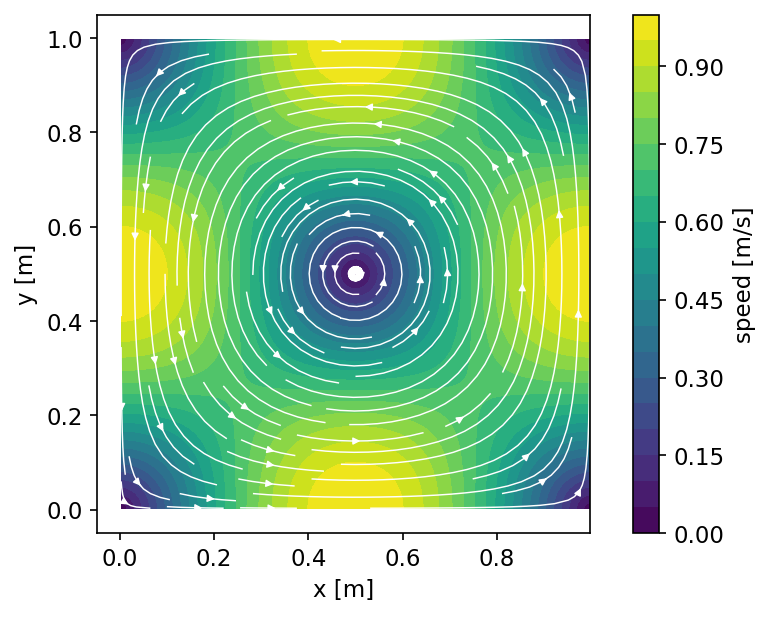

In [8]:
# figures/fig0-cover.png : Taylor-Green field, streamlines over the speed
xc, Xc, Yc, dxc = grid(N_FINE)
uc, vc = field_a(Xc, Yc)
speed = np.hypot(uc, vc)

fig, ax = plt.subplots()
m = ax.contourf(Xc, Yc, speed, levels=21, cmap="viridis")
ax.streamplot(xc, xc, uc, vc, color="white", linewidth=0.7, density=1.1, arrowsize=0.7)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
fig.colorbar(m, ax=ax, label="speed [m/s]")
fig.savefig(f"{FIG}/fig0-cover.png")
plt.show()

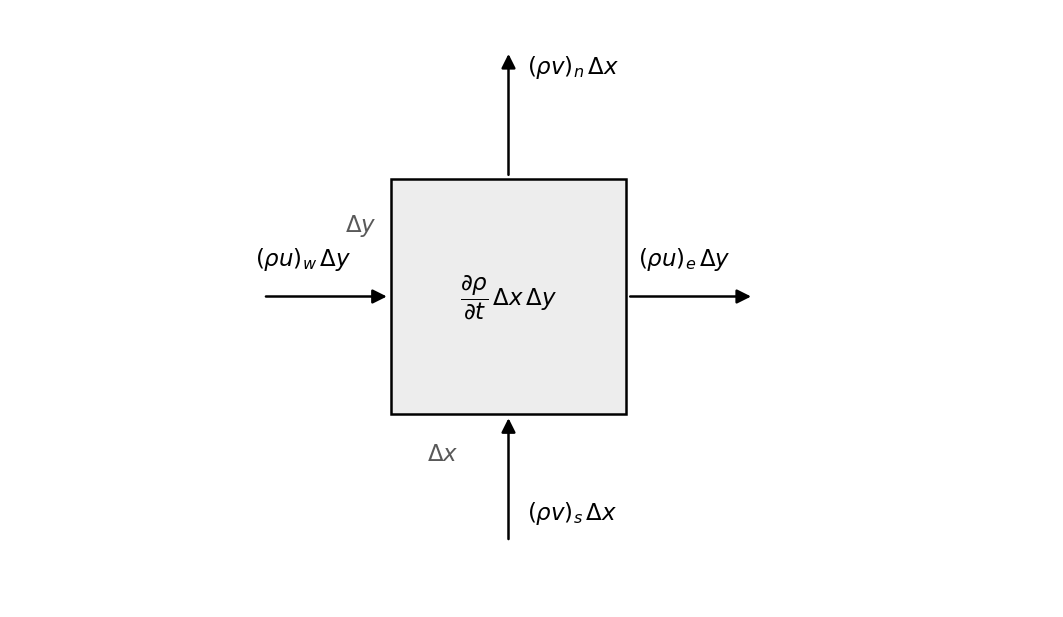

In [9]:
# figures/fig1-sketch.png : mass flow through the faces of one cell
fig, ax = plt.subplots()
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fc="0.93", ec="k", lw=1.2))
arrow = dict(arrowstyle="-|>", color="k", lw=1.2, mutation_scale=14)

ax.annotate("", xy=(0, 0.5), xytext=(-0.55, 0.5), arrowprops=arrow)
ax.annotate("", xy=(1.55, 0.5), xytext=(1, 0.5), arrowprops=arrow)
ax.annotate("", xy=(0.5, 0), xytext=(0.5, -0.55), arrowprops=arrow)
ax.annotate("", xy=(0.5, 1.55), xytext=(0.5, 1), arrowprops=arrow)

ax.text(-0.58, 0.60, r"$(\rho u)_w\,\Delta y$", ha="left", va="bottom")
ax.text(1.05, 0.60, r"$(\rho u)_e\,\Delta y$", ha="left", va="bottom")
ax.text(0.58, -0.48, r"$(\rho v)_s\,\Delta x$", ha="left", va="bottom")
ax.text(0.58, 1.42, r"$(\rho v)_n\,\Delta x$", ha="left", va="bottom")
ax.text(0.5, 0.5, r"$\dfrac{\partial\rho}{\partial t}\,\Delta x\,\Delta y$",
        ha="center", va="center")

ax.text(0.22, -0.12, r"$\Delta x$", ha="center", va="top", color="0.35")
ax.text(-0.06, 0.80, r"$\Delta y$", ha="right", va="center", color="0.35")

ax.set_xlim(-1.60, 2.80)
ax.set_ylim(-0.80, 1.70)
ax.set_aspect("equal")
ax.axis("off")
fig.savefig(f"{FIG}/fig1-sketch.png")
plt.show()

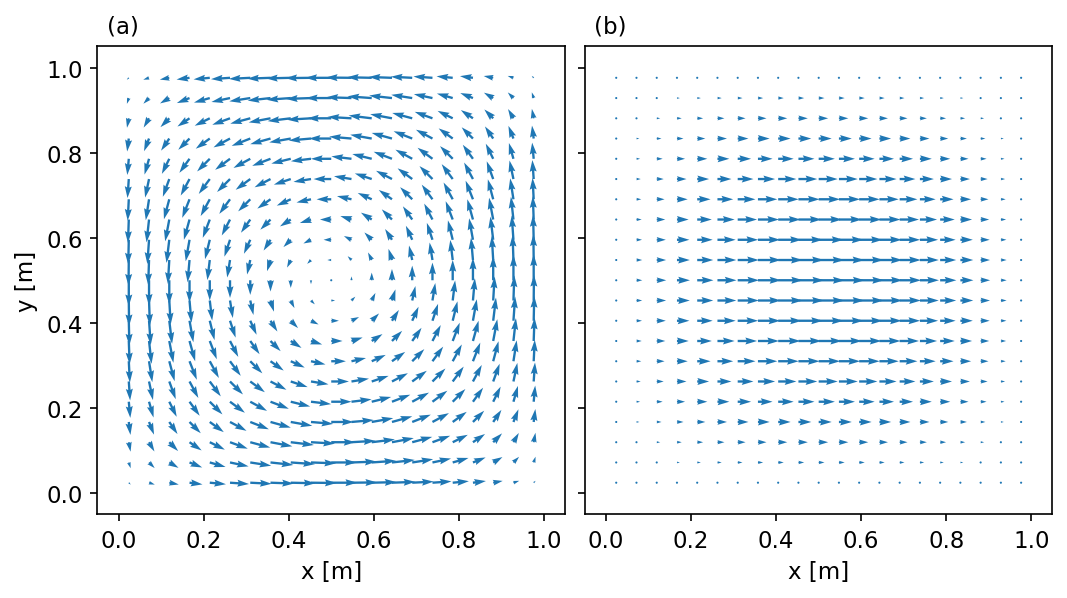

In [10]:
# figures/fig2-fields.png : the two velocity fields
xq, Xq, Yq, dxq = grid(21)
uqA, vqA = field_a(Xq, Yq)
uqB, vqB = field_b(Xq, Yq)

fig, axes = plt.subplots(1, 2, sharey=True)
for ax, (u, v), tag in zip(axes, ((uqA, vqA), (uqB, vqB)), ("(a)", "(b)")):
    ax.quiver(Xq, Yq, u, v, scale=18, width=0.005, color="#1f77b4")
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.text(0.02, 1.02, tag, transform=ax.transAxes, va="bottom")
axes[0].set_ylabel("y [m]")
fig.savefig(f"{FIG}/fig2-fields.png")
plt.show()

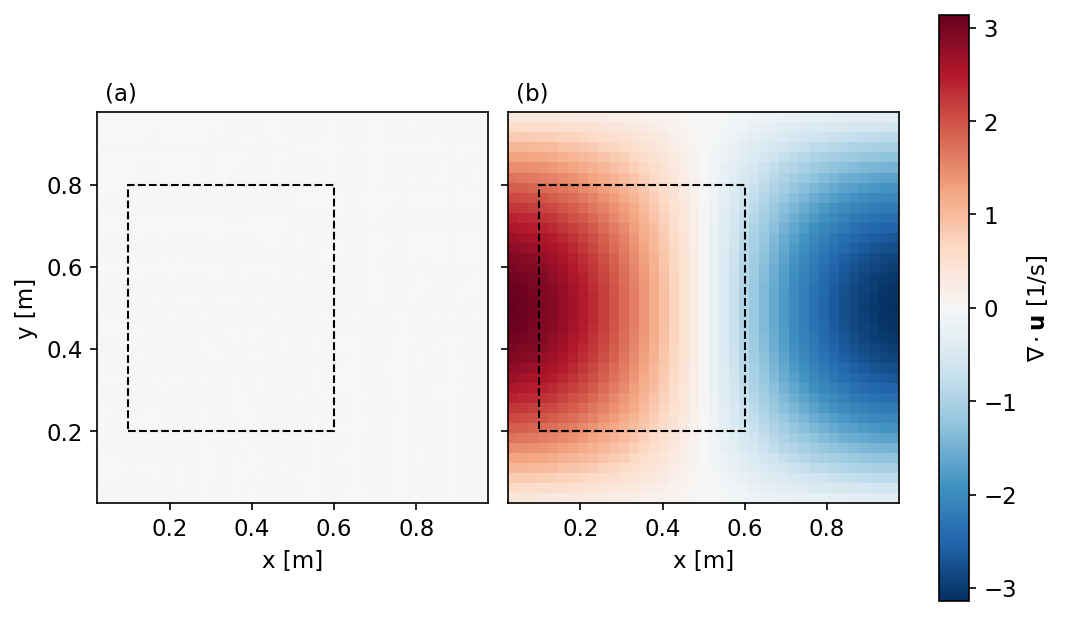

In [11]:
# figures/fig3-divergence.png : discrete divergence of both fields, same scale,
# with the control volume of Step 5 drawn as a dashed line
lim = np.pi * U0 / L

fig, axes = plt.subplots(1, 2, sharey=True)
for ax, d, tag in zip(axes, (dA, dB), ("(a)", "(b)")):
    m = ax.pcolormesh(X[1:-1, 1:-1], Y[1:-1, 1:-1], d[1:-1, 1:-1],
                      cmap="RdBu_r", vmin=-lim, vmax=lim, shading="nearest")
    ax.add_patch(plt.Rectangle((BOX[0], BOX[2]), BOX[1] - BOX[0], BOX[3] - BOX[2],
                               fill=False, ec="k", lw=1.0, ls="--"))
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal")
    ax.text(0.02, 1.02, tag, transform=ax.transAxes, va="bottom")
axes[0].set_ylabel("y [m]")
fig.colorbar(m, ax=axes, label=r"$\nabla\cdot\mathbf{u}$ [1/s]")
fig.savefig(f"{FIG}/fig3-divergence.png")
plt.show()

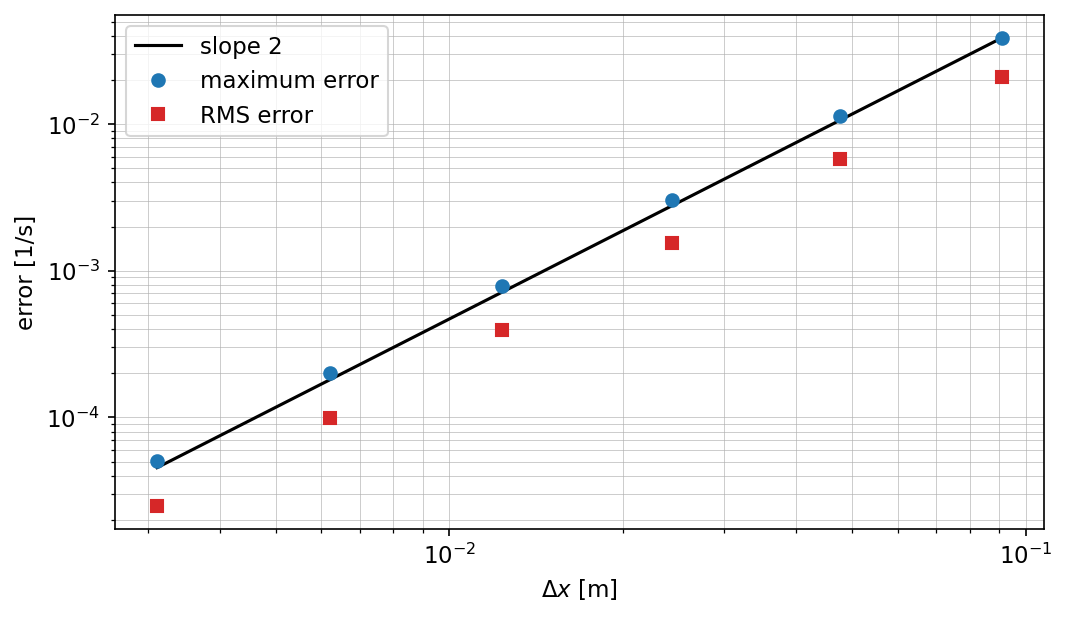

In [12]:
# figures/fig4-convergence.png : error of the discrete divergence against dx
dxs = np.array([r[1] for r in rows])
e_max_all = np.array([r[2] for r in rows])
e_rms_all = np.array([r[3] for r in rows])
ref = e_max_all[0] * (dxs / dxs[0]) ** 2

fig, ax = plt.subplots()
ax.loglog(dxs, ref, "k-", label="slope 2")
ax.loglog(dxs, e_max_all, "o", color="#1f77b4", label="maximum error")
ax.loglog(dxs, e_rms_all, "s", color="#d62728", label="RMS error")
ax.set_xlabel(r"$\Delta x$ [m]")
ax.set_ylabel("error [1/s]")
ax.grid(True, which="both", lw=0.3)
ax.legend()
fig.savefig(f"{FIG}/fig4-convergence.png")
plt.show()

## Try it yourself

Change the values in Step 1 and run all cells again.

- Replace `field_b` with a field of your own and work out `div_b_exact` by hand. The
  slope in the last figure stays at 2 for any smooth field.
- Move `BOX` anywhere inside the domain and change its shape. The surface integral for
  field A stays at round-off level, because field A conserves mass over every control
  volume, not only over the one used here.
- Replace the central difference in `divergence` with the one-sided form
  $(u_{i,j}-u_{i-1,j})/\Delta x$ and run Step 6 again. The slope drops to 1.